<a href="https://colab.research.google.com/github/aishruban5566-ctrl/mlt-programs/blob/main/task_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
   Feature1  Feature2
0  3.205262  1.432103
1  1.456094  1.452747
2  3.658032  0.217585
3  1.099112  0.301756
4  3.275439  6.507825

K-Means Labels:
 [0 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 0 0 1 1 1
 0 1 1 1 0 0 1 1 0 1 1 1 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 1 0 1 0 1 1 0 1 0 0
 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0
 1 1 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1
 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 1
 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1]

EM (GMM) Labels:
 [1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1 1 1 0 0 0
 1 0 0 0 1 1 0 0 1 0 0 0 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 1 0 1 1
 1 1 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 0 1
 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 0 1 0 1 0 1 1 1 0 1 0 0 1 1 0 0
 1 1 1 0 0 0 1 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0
 0 1 1 1 0 1 0 1 1 1 1 0

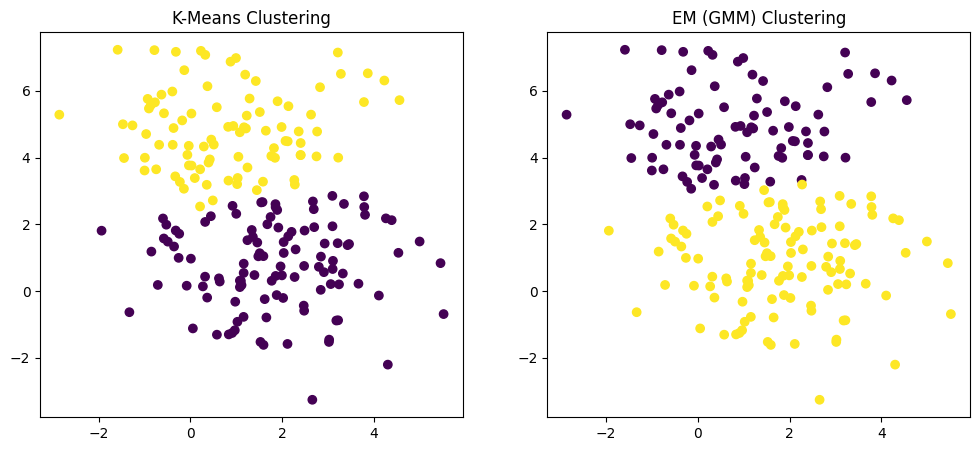


K-Means Silhouette Score: 0.4579662633787065
EM (GMM) Silhouette Score: 0.45780291558937264

--- Comparison Result ---
K-Means gives better clustering.

Conclusion:
K-Means works well for simple, spherical clusters.
EM (GMM) works better for overlapping and complex clusters.


In [ ]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

# Step 2: Generate dataset (instead of CSV)
X, y_true = make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=0)

# Convert to DataFrame (optional)
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

print("First 5 rows of dataset:")
print(df.head())

# Step 3: Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

print("\nK-Means Labels:\n", kmeans_labels)

# Step 4: Apply EM (GMM)
gmm = GaussianMixture(n_components=2, random_state=0)
gmm_labels = gmm.fit_predict(X)

print("\nEM (GMM) Labels:\n", gmm_labels)

# Step 5: Visualization
plt.figure(figsize=(12, 5))

# K-Means Plot
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")

# EM Plot
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, cmap='viridis')
plt.title("EM (GMM) Clustering")

plt.show()

# Step 6: Evaluation
kmeans_score = silhouette_score(X, kmeans_labels)
gmm_score = silhouette_score(X, gmm_labels)

print("\nK-Means Silhouette Score:", kmeans_score)
print("EM (GMM) Silhouette Score:", gmm_score)

# Step 7: Comparison
print("\n--- Comparison Result ---")

if kmeans_score > gmm_score:
    print("K-Means gives better clustering.")
elif gmm_score > kmeans_score:
    print("EM (GMM) gives better clustering.")
else:
    print("Both perform equally well.")

print("\nConclusion:")
print("K-Means works well for simple, spherical clusters.")
print("EM (GMM) works better for overlapping and complex clusters.")